Avocado Price Prediction and Type Classification Using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
avocado= pd.read_csv("C:/Users/Khaled/Documents/avocado.csv")
avocado.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [3]:
avocado.info()
avocado.describe()
avocado.isna().sum()
avocado.duplicated()
avocado.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


Index(['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225',
       '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type',
       'year', 'region'],
      dtype='object')

In [4]:
avocado2 = avocado.copy()
avocado2.columns = avocado2.columns.str.lower().str.strip()
print(avocado2.columns.tolist())

['unnamed: 0', 'date', 'averageprice', 'total volume', '4046', '4225', '4770', 'total bags', 'small bags', 'large bags', 'xlarge bags', 'type', 'year', 'region']


In [5]:
avocado2['date'] = pd.to_datetime(avocado2['date'])

avocado2['month'] = avocado2['date'].dt.month
avocado2['day'] = avocado2['date'].dt.day

avocado2.head()

,unnamed: 0,date,averageprice,total volume,4046,4225,4770,total bags,small bags,large bags,xlarge bags,type,year,region,month,day
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12,27
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12,20
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12,13
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12,6
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11,29


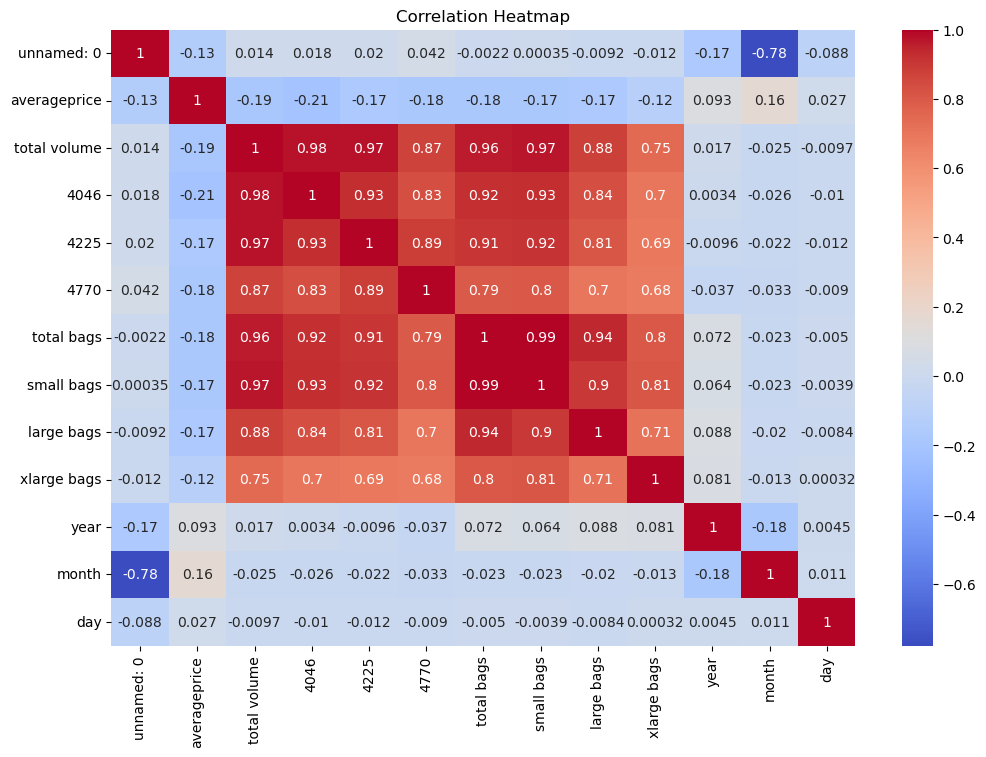

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(avocado2.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

PART 1: PRICE PREDICTION

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
features = ['total volume']
x = avocado2[features]
y = avocado2['averageprice']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
x_train.head()
x_test.head()
y_train.head()
y_test.head()

8604     0.82
2608     0.97
14581    1.44
4254     0.97
16588    1.45
Name: averageprice, dtype: float64

In [27]:
avocado_model = LinearRegression()
avocado_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred = avocado_model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R² Score:', r2)

RMSE: 0.39406238974591185
R² Score: 0.03350934849606935


In [9]:
features = ['total volume', '4046', '4225', '4770', 'total bags', 'month']
x = avocado2[features]
y = avocado2['averageprice']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [40]:
x_train.head()
x_test.head()
y_train.head()
y_test.head()

8604     0.82
2608     0.97
14581    1.44
4254     0.97
16588    1.45
Name: averageprice, dtype: float64

In [29]:
avocado_model2 = LinearRegression()
avocado_model2.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred2 = avocado_model.predict(x_test)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred))
r2_2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R² Score:', r2)

RMSE: 0.39406238974591185
R² Score: 0.03350934849606935


Model Performance & Interpretation
using Total Volume as the single predictor for Average Price, yielded the following:
RMSE: 0.39
This indicates that, on average, the model’s predictions deviate from the actual price by approximately $0.39. Given the typical price range of avocados, this represents a relatively high margin of error.

R² Score: 0.073
The R² value suggests that only 7.3% of the variance in avocado prices is explained by the total volume. This confirms that while a relationship exists, volume alone is not a strong enough predictor for accurate price forecasting.

This means that this prediction is underfitting the data.


In [ ]:
PART 2:Avocado Type Classification

In [13]:
avocado3 = pd.get_dummies(avocado2, columns=['type'], drop_first=True, dtype=int)
avocado3.head(5)



,unnamed: 0,date,averageprice,total volume,4046,4225,4770,total bags,small bags,large bags,xlarge bags,year,region,month,day,type_organic
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,2015,Albany,12,27,0
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,2015,Albany,12,20,0
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,2015,Albany,12,13,0
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,2015,Albany,12,6,0
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,2015,Albany,11,29,0


In [17]:
from sklearn.linear_model import LogisticRegression

X = avocado3[['total volume', 'type_organic']]
y = avocado3['averageprice']
y_binary = (y > 1.5).astype(int) 

avocado_model_multi = LogisticRegression(max_iter=1000)
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)
avocado_model_multi.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
y_pred = avocado_model_multi.predict(X_test)

array([0, 0, 1, ..., 0, 1, 1], shape=(3650,))

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.7619178082191781

In [22]:
avocado_cm = confusion_matrix(y_test, y_pred)
avocado_cm


array([[1601,  650],
       [ 219, 1180]])

In [23]:
precision = precision_score(y_test, y_pred)
precision

0.644808743169399

In [24]:
recall = recall_score(y_test, y_pred)
recall


0.8434596140100071

Including the variable 'Type' significantly enhanced the model’s predictive power. The R² score increased from 7.3% to 36.5%, indicating that the price distinction between organic and conventional avocados is a critical factor in market valuation. While the error (RMSE) was reduced to $0.32, the model still has room for improvement.

The region column contains over 50 unique locations,so Label Encoding will be used to assigns a unique number 0-53 to each city/area

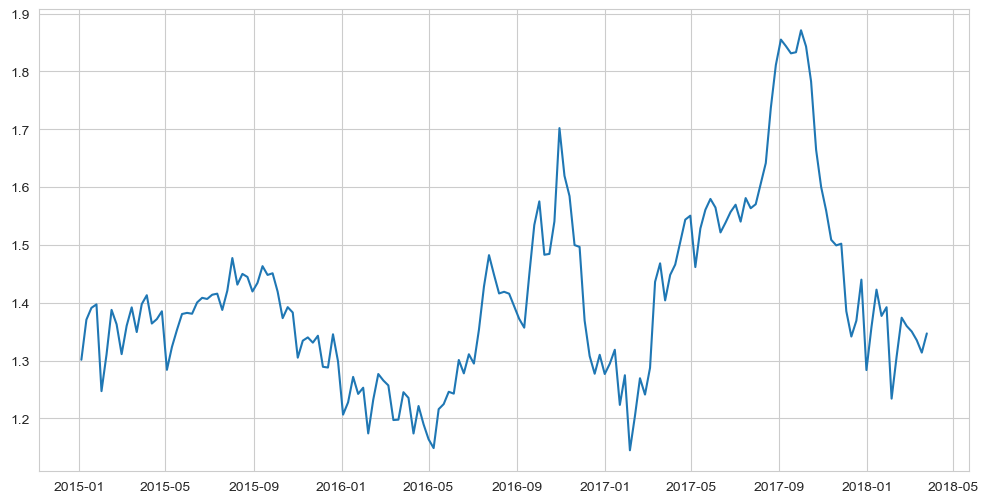

ADF Statistic: -2.357816524766645
p-value: 0.15399792321893607


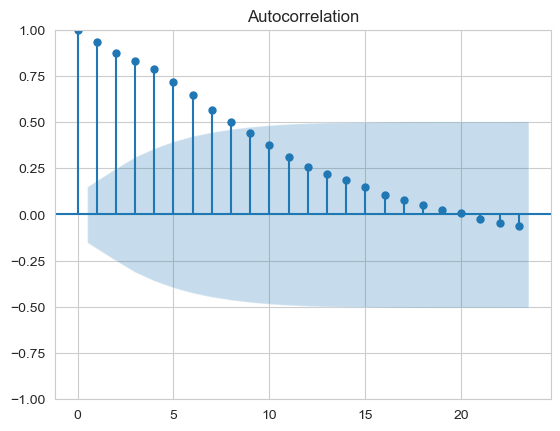

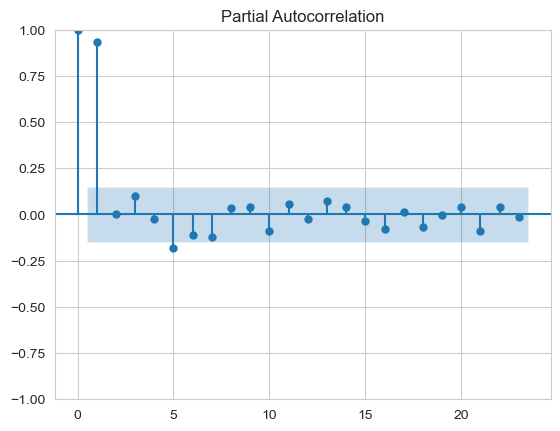

C:\Users\Khaled\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
C:\Users\Khaled\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
C:\Users\Khaled\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.


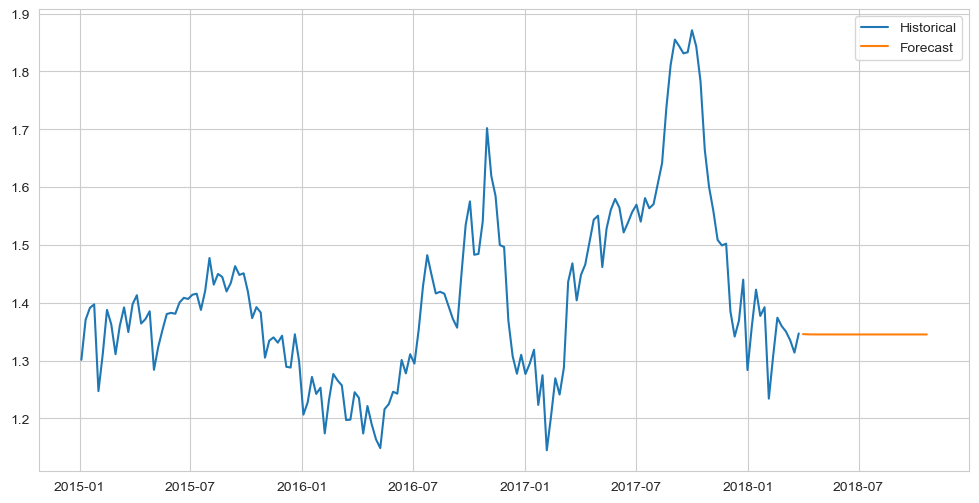

In [75]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

ts = avocado3.groupby('date')['averageprice'].mean()

plt.figure(figsize=(12,6))
plt.plot(ts)
plt.show()

result = adfuller(ts)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

plot_acf(ts)
plt.show()
plot_pacf(ts)
plt.show()

model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=30)
ts.index.freq = 'W-SUN'
plt.figure(figsize=(12,6))
plt.plot(ts, label='Historical')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()

In [58]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
avocado3['region_encoded'] = le.fit_transform(avocado3['region'])
avocado3

,unnamed: 0,date,averageprice,total volume,4046,4225,4770,total bags,small bags,large bags,xlarge bags,year,region,month,day,type_organic,region_encoded
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,2015,Albany,12,27,0,0
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,2015,Albany,12,20,0,0
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,2015,Albany,12,13,0,0
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,2015,Albany,12,6,0,0
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,2015,Albany,11,29,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,7,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,2018,WestTexNewMexico,2,4,1,53
18245,8,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,2018,WestTexNewMexico,1,28,1,53
18246,9,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,2018,WestTexNewMexico,1,21,1,53
18247,10,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,2018,WestTexNewMexico,1,14,1,53


In [59]:
features = ['total volume', 'type_organic', 'region_encoded', 'month']
X = avocado3[features]
y = avocado3['averageprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

avocado_model_full = LinearRegression()
avocado_model_full.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [61]:
y_pred = avocado_model_full.predict(X_test)

rmse3 = np.sqrt(mean_squared_error(y_test, y_pred))
print (rmse3)

r2_3 = r2_score(y_test, y_pred)
print(r2_3)


0.3118279895491432
0.3948014573905818


The final result of the Linear Regression model achieved an R² of 0.395 and an RMSE of $0.31. By moving from a single feature model (Volume only) to a multiple feature model (Volume, Type, Region, and Month), The model’s explained variance was increased from 7% to nearly 40%. This progression illustrates that while supply volume drives the baseline price, the other factors such as organic status and the geographic/seasonal variations are the primary factors behind price fluctuations.

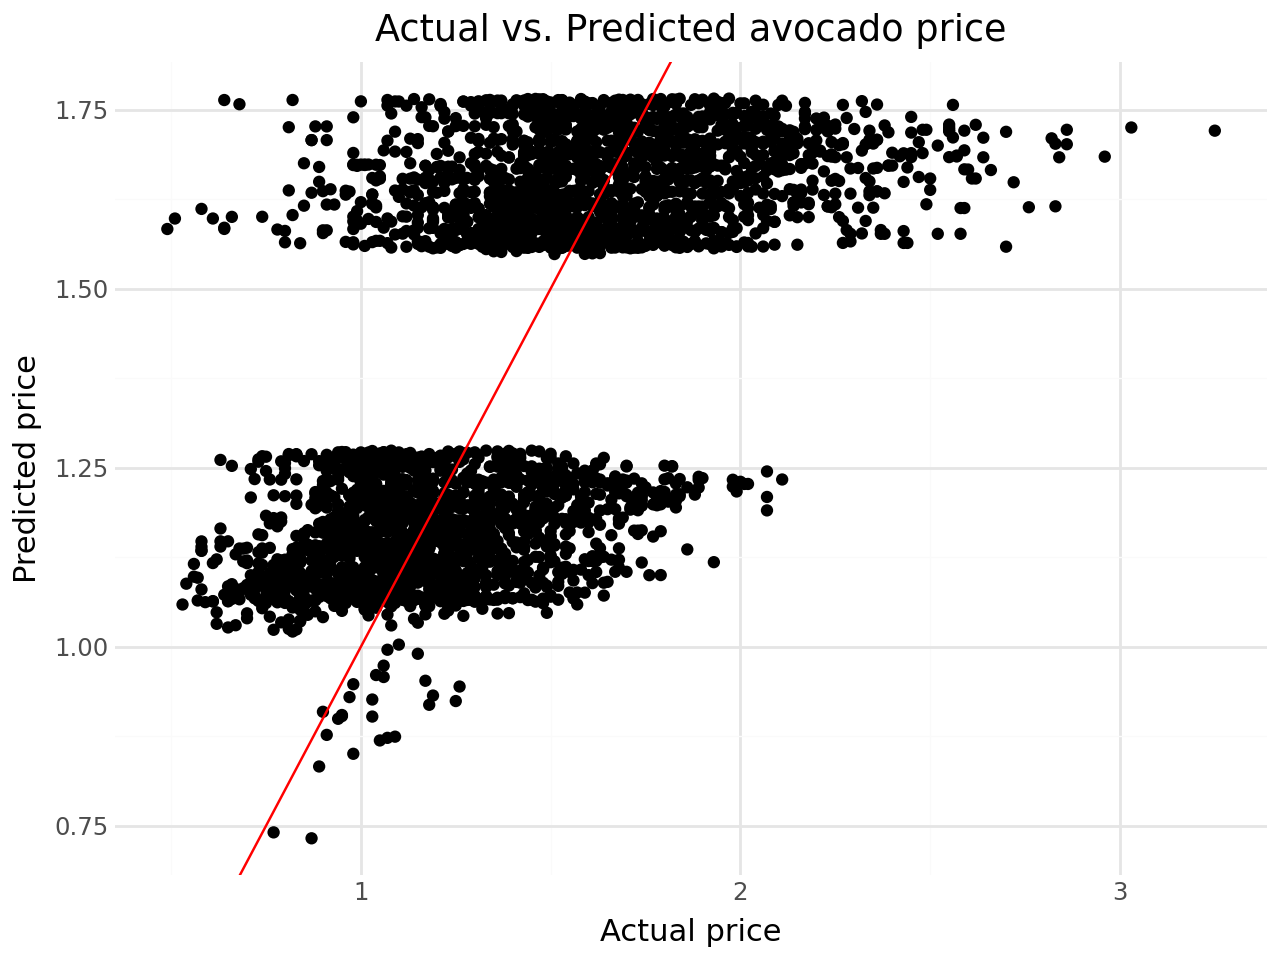

In [63]:
from plotnine import ggplot, aes, geom_point, geom_abline, theme_minimal, labs
y_pred = avocado_model_full.predict(X_test)

results_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred})

(ggplot(results_df, aes(x="actual", y="predicted"))
    + geom_point()
    + geom_abline(intercept=0, slope=1, color="red", linetype="---") 
    + theme_minimal()
    + labs(
        title="Actual vs. Predicted avocado price",
        x="Actual price",
        y="Predicted price"))

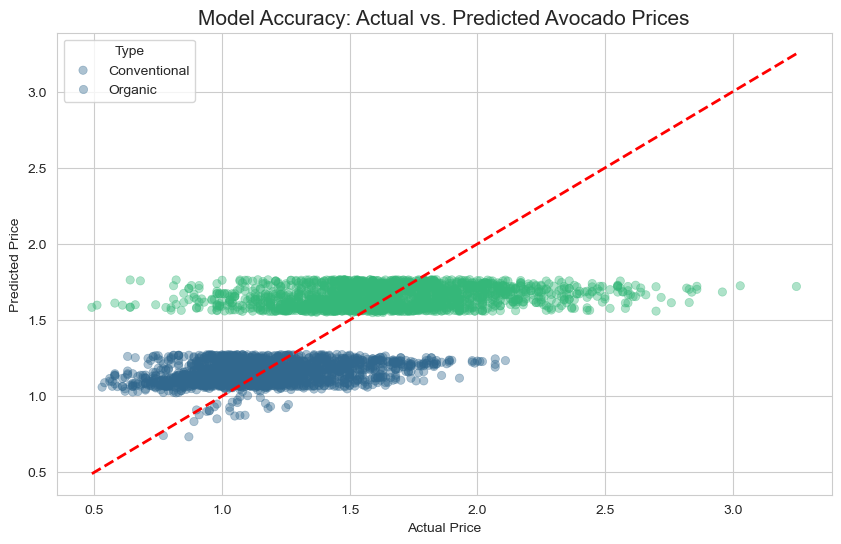

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style()

sns.scatterplot(x=y_test, y=y_pred, hue=X_test['type_organic'], 
                alpha=0.4, palette='viridis', edgecolor=None)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', lw=2, linestyle='--')

plt.title('Model Accuracy: Actual vs. Predicted Avocado Prices', fontsize=15)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.legend(title='Type', labels=['Conventional', 'Organic'])

plt.show()